# An Automated ER Triage Optimizer

## Project Overview
This notebook contains the Automated ER Triage Optimizer pipeline using PySpark. The objective of this project is to process complex,relational Symptom-to-Disease Medical data and train a distributed PCA-optimized Random Forest classifier to predict patient triage priority (**RED**, **YELLOW**, or **GREEN**).

## Dataset
* **Source:** Symptom-to-Disease Medical Dataset | URL: https://www.kaggle.com/datasets/harrachimustapha/symptom-to-disease-medical-dataset/data
* **Disclaimer:** This data is strictly synthetic and utilized exclusively for academic algorithmic benchmarking. It is not intended for real-world clinical diagnosis.

**Environment Setup:** Ensure that `pyspark` and `jupyter` are installed in the active Python interpreter before executing the cells below.

## Install PySpark
---

In [3]:
!pip install pyspark

In [4]:
import pyspark

In [5]:
print(f"PySpark Wrapper Version: {pyspark.__version__}")

PySpark Wrapper Version: 4.0.2


### Initialize the Spark Session

In [6]:
from pyspark.sql import SparkSession

In [7]:
spark = SparkSession.builder \
    .appName("ERTriageOptimizer") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark Session successfully created!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/23 16:41:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Session successfully created!


In [8]:
print(f"Apache Spark Engine Version: {spark.version}")

Apache Spark Engine Version: 4.0.2


## Data Preprocessing
---

### Data Ingestion

In [9]:
patients_df = spark.read.csv("/data/input/patients.csv", header=True, inferSchema=True)

In [10]:
patients_df.show(5)

+----------+---+---+-----------------------+-------------------------+--------------------+-------------------+-------------------------+-------------+--------------------------+-----+
|patient_id|age|sex|ground_truth_disease_id|ground_truth_disease_name|initial_evidence_raw|initial_evidence_id|initial_evidence_value_id|num_evidences|num_differential_diagnoses|split|
+----------+---+---+-----------------------+-------------------------+--------------------+-------------------+-------------------------+-------------+--------------------------+-----+
|  P0000001| 18|  M|                   D038|                     URTI|                E_91|               E_91|                     NULL|           19|                         8|train|
|  P0000002| 21|  M|                   D006|     HIV (initial infe...|                E_50|               E_50|                     NULL|           31|                         4|train|
|  P0000003| 19|  F|                   D040|                Pneumonia|     

In [ ]:
patient_evidences_df = spark.read.csv("/data/input/patient_evidences.csv", header=True, inferSchema=True)

In [11]:
patient_evidences_df.show(5)

+----------+------------+-----------+-----------------+-------------+---------+-------------------+-----+
|patient_id|evidence_raw|evidence_id|evidence_value_id|evidence_type|data_type|is_initial_evidence|split|
+----------+------------+-----------+-----------------+-------------+---------+-------------------+-----+
|  P0000001|        E_48|       E_48|             NULL|   antecedent|        B|              false|train|
|  P0000001|        E_50|       E_50|             NULL|      symptom|        B|              false|train|
|  P0000001|        E_53|       E_53|             NULL|      symptom|        B|              false|train|
|  P0000001|E_54_@_V_161|       E_54|            V_161|      symptom|        M|              false|train|
|  P0000001|E_54_@_V_183|       E_54|            V_183|      symptom|        M|              false|train|
+----------+------------+-----------+-----------------+-------------+---------+-------------------+-----+
only showing top 5 rows


In [ ]:
diseases_df = spark.read.csv("/data/input/diseases.csv", header=True, inferSchema=True)

In [12]:
diseases_df.show(5)

+----------+--------------------+--------------------+--------+--------+--------------------+-----------------------+
|disease_id|        disease_name|     disease_name_en|icd10_id|severity|num_defined_symptoms|num_defined_antecedents|
+----------+--------------------+--------------------+--------+--------+--------------------+-----------------------+
|      D001|Spontaneous pneum...|Spontaneous pneum...|     J93|       2|                  12|                      5|
|      D002|    Cluster headache|    Cluster headache| g44.009|       3|                  10|                      4|
|      D003|           Boerhaave|           Boerhaave|   K22.3|       2|                  11|                      2|
|      D004|Spontaneous rib f...|Spontaneous rib f...|   S22.9|       3|                  13|                      4|
|      D005|                GERD|                GERD|     K21|       3|                  13|                      7|
+----------+--------------------+--------------------+--

### Data Cleaning

In [13]:
patients_df = patients_df.drop(
    "ground_truth_disease_name",
    "num_differential_diagnoses",
    "initial_evidence_raw",
    "split"
)

In [14]:
patients_df.show(5)

+----------+---+---+-----------------------+-------------------+-------------------------+-------------+
|patient_id|age|sex|ground_truth_disease_id|initial_evidence_id|initial_evidence_value_id|num_evidences|
+----------+---+---+-----------------------+-------------------+-------------------------+-------------+
|  P0000001| 18|  M|                   D038|               E_91|                     NULL|           19|
|  P0000002| 21|  M|                   D006|               E_50|                     NULL|           31|
|  P0000003| 19|  F|                   D040|               E_77|                     NULL|           34|
|  P0000004| 34|  F|                   D038|               E_53|                     NULL|           16|
|  P0000005| 36|  M|                   D038|              E_201|                     NULL|           17|
+----------+---+---+-----------------------+-------------------+-------------------------+-------------+
only showing top 5 rows


In [15]:
patient_evidences_df = patient_evidences_df.drop("evidence_raw", "split")

In [16]:
patient_evidences_df.show(5)

+----------+-----------+-----------------+-------------+---------+-------------------+
|patient_id|evidence_id|evidence_value_id|evidence_type|data_type|is_initial_evidence|
+----------+-----------+-----------------+-------------+---------+-------------------+
|  P0000001|       E_48|             NULL|   antecedent|        B|              false|
|  P0000001|       E_50|             NULL|      symptom|        B|              false|
|  P0000001|       E_53|             NULL|      symptom|        B|              false|
|  P0000001|       E_54|            V_161|      symptom|        M|              false|
|  P0000001|       E_54|            V_183|      symptom|        M|              false|
+----------+-----------+-----------------+-------------+---------+-------------------+
only showing top 5 rows


In [17]:
diseases_df = diseases_df.drop(
    "disease_name",
    "disease_name_en",
    "icd10_id",
    "num_defined_symptoms",
    "num_defined_antecedents"
)

In [18]:
diseases_df.show(5)

+----------+--------+
|disease_id|severity|
+----------+--------+
|      D001|       2|
|      D002|       3|
|      D003|       2|
|      D004|       3|
|      D005|       3|
+----------+--------+
only showing top 5 rows


### Distributed Joins

In [19]:
from pyspark.sql.functions import collect_list

In [20]:
patients_evidences_agg_df = patient_evidences_df.groupBy("patient_id") \
    .agg(collect_list("evidence_id").alias("symptoms_array"))

In [21]:
patients_evidences_agg_df.show(5)

+----------+--------------------+
|patient_id|      symptoms_array|
+----------+--------------------+
|  P0000003|[E_53, E_54, E_54...|
|  P0000006|[E_53, E_54, E_54...|
|  P0000011|[E_86, E_87, E_12...|
|  P0000014|[E_12, E_42, E_51...|
|  P0000017|[E_25, E_53, E_54...|
+----------+--------------------+
only showing top 5 rows


In [22]:
patients_with_symptoms_df = patients_df.join(
    patients_evidences_agg_df, on="patient_id", how="inner"
)

In [23]:
patients_with_symptoms_df.show(5)

+----------+---+---+-----------------------+-------------------+-------------------------+-------------+--------------------+
|patient_id|age|sex|ground_truth_disease_id|initial_evidence_id|initial_evidence_value_id|num_evidences|      symptoms_array|
+----------+---+---+-----------------------+-------------------+-------------------------+-------------+--------------------+
|  P0000003| 19|  F|                   D040|               E_77|                     NULL|           34|[E_53, E_54, E_54...|
|  P0000006| 37|  F|                   D042|               E_53|                     NULL|           27|[E_53, E_54, E_54...|
|  P0000011|  8|  M|                   D020|              E_169|                     NULL|            8|[E_86, E_87, E_12...|
|  P0000014| 49|  F|                   D012|              E_159|                     NULL|           37|[E_12, E_42, E_51...|
|  P0000017| 57|  F|                   D002|               E_53|                     NULL|           21|[E_25, E_53, E

In [24]:
master_df = patients_with_symptoms_df.join(
    diseases_df,
    patients_with_symptoms_df.ground_truth_disease_id == diseases_df.disease_id,
    how="inner"
).drop("patient_id", "ground_truth_disease_id", "disease_id")

In [25]:
master_df.show(5)

+---+---+-------------------+-------------------------+-------------+--------------------+--------+
|age|sex|initial_evidence_id|initial_evidence_value_id|num_evidences|      symptoms_array|severity|
+---+---+-------------------+-------------------------+-------------+--------------------+--------+
| 19|  F|               E_77|                     NULL|           34|[E_53, E_54, E_54...|       3|
| 37|  F|               E_53|                     NULL|           27|[E_53, E_54, E_54...|       5|
|  8|  M|              E_169|                     NULL|            8|[E_86, E_87, E_12...|       4|
| 49|  F|              E_159|                     NULL|           37|[E_12, E_42, E_51...|       1|
| 57|  F|               E_53|                     NULL|           21|[E_25, E_53, E_54...|       3|
+---+---+-------------------+-------------------------+-------------+--------------------+--------+
only showing top 5 rows


### Export Master Dataset

In [26]:
master_pandas_df = master_df.toPandas()

In [27]:
master_pandas_df.to_csv("/data/output/master_dataset.csv", index=False)

### Encoding Categorical Variables

In [28]:
from pyspark.sql.functions import col, when, round
from pyspark.ml.feature import CountVectorizer, StringIndexer

In [29]:
master_df = master_df.withColumn(
    "triage_priority",
    when(col("severity") >= 4, "RED")
    .when(col("severity") == 3, "YELLOW")
    .otherwise("GREEN")
).drop("severity") 

In [30]:
indexer = StringIndexer(inputCol="triage_priority", outputCol="label")

### Explorative Analysis

In [31]:
total_rows = master_df.count()
print(f"Total number of records: {total_rows}\n")

Total number of records: 1292579



In [32]:
balance_df = master_df.groupBy("triage_priority").count()

In [33]:
balance_df = balance_df.withColumn(
    "Percentage (%)", 
    round((col("count") / total_rows) * 100, 2)
)

In [34]:
balance_df.show()

+---------------+------+--------------+
|triage_priority| count|Percentage (%)|
+---------------+------+--------------+
|            RED|540859|         41.84|
|          GREEN|362316|         28.03|
|         YELLOW|389404|         30.13|
+---------------+------+--------------+



---

## Feature Engineering
---

In [35]:
from pyspark.ml.feature import PCA

In [36]:
vectorizer = CountVectorizer(inputCol="symptoms_array", outputCol="features")

In [37]:
pca = PCA(k=50, inputCol="features", outputCol="compressed_features")

---

## Preparing Pipeline
---

In [38]:
train_data, test_data = master_df.randomSplit([0.8, 0.2], seed=42)

In [39]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

In [40]:
acc_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
prec_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
f1_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

---

## Model
---

### Random Forest Classifier

In [41]:
from pyspark.ml.classification import RandomForestClassifier

In [42]:
rf_classifier = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=50
)

triage_pipeline = Pipeline(stages=[vectorizer, indexer, rf_classifier])

In [43]:
rf_model = triage_pipeline.fit(train_data)

In [44]:
rf_pred = rf_model.transform(test_data)

In [45]:
rf_acc = acc_eval.evaluate(rf_pred)
rf_prec = prec_eval.evaluate(rf_pred)
rf_f1 = f1_eval.evaluate(rf_pred)

In [46]:
print("Random Forest Classifier")
print(f"Accuracy: {rf_acc}")
print(f"Precision: {rf_prec}")
print(f"F1 Score: {rf_f1}")

Random Forest Classifier
Accuracy: 0.8165057881502253
Precision: 0.8367057615027271
F1 Score: 0.8171168885903435


### PCA-Optimized Random Forest Classifier

In [47]:
rf_classifier = RandomForestClassifier(
    featuresCol="compressed_features",
    labelCol="label",
    numTrees=50
)

pca_rf_pipeline = Pipeline(stages=[vectorizer, pca, indexer, rf_classifier])

In [48]:
pca_rf_model = pca_rf_pipeline.fit(train_data)

In [49]:
pca_rf_pred = pca_rf_model.transform(test_data)

In [50]:
pca_rf_acc = acc_eval.evaluate(pca_rf_pred)
pca_rf_prec = prec_eval.evaluate(pca_rf_pred)
pca_rf_f1 = f1_eval.evaluate(pca_rf_pred)

In [51]:
print(f"PCA-Optimized Random Forest:")
print(f"Accuracy:  {pca_rf_acc}")
print(f"Precision: {pca_rf_prec}")
print(f"F1-Score:  {pca_rf_f1}")

PCA-Optimized Random Forest:
Accuracy:  0.9325237262013744
Precision: 0.9371766612614295
F1-Score:  0.9320962564274694


### Logistic Regression

In [52]:
from pyspark.ml.classification import LogisticRegression

In [53]:
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)
lr_pipeline = Pipeline(stages=[vectorizer, indexer, lr])
lr_model = lr_pipeline.fit(train_data)

In [54]:
lr_pred = lr_model.transform(test_data)

In [55]:
lr_acc = acc_eval.evaluate(lr_pred)
lr_prec = prec_eval.evaluate(lr_pred)
lr_f1 = f1_eval.evaluate(lr_pred)

In [56]:
print("Logistic Regression")
print(f"Accuracy: {lr_acc}")
print(f"Precision: {lr_prec}")
print(f"F1 Score: {lr_f1}")

Logistic Regression
Accuracy: 0.99809572368294
Precision: 0.9980987913095334
F1 Score: 0.998095788055247


### PCA-Optimized Logistic Regression

In [57]:
print("Training the model...")
pca_lr = LogisticRegression(featuresCol="compressed_features", labelCol="label", maxIter=10)
pca_lr_pipeline = Pipeline(stages=[vectorizer, pca, indexer, pca_lr])
pca_lr_model = pca_lr_pipeline.fit(train_data)
print("Complete")

Training the model...


Complete


In [58]:
pca_lr_pred = pca_lr_model.transform(test_data)

In [59]:
pca_lr_acc = acc_eval.evaluate(pca_lr_pred)
pca_lr_prec = prec_eval.evaluate(pca_lr_pred)
pca_lr_f1 = f1_eval.evaluate(pca_lr_pred)

In [60]:
print("PCA-Optimized Logistic Regression")
print(f"Accuracy: {pca_lr_acc}")
print(f"Precision: {pca_lr_prec}")
print(f"F1 Score: {pca_lr_f1}")

PCA-Optimized Logistic Regression
Accuracy: 0.9928618607831095
Precision: 0.992863216882647
F1 Score: 0.992861368335731


### Decision Tree Classifier

In [61]:
from pyspark.ml.classification import DecisionTreeClassifier

In [62]:
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")
dt_pipeline = Pipeline(stages=[vectorizer, indexer, dt])
dt_model = dt_pipeline.fit(train_data)

In [63]:
dt_pred = dt_model.transform(test_data)

In [64]:
dt_acc = acc_eval.evaluate(dt_pred)
dt_prec = prec_eval.evaluate(dt_pred)
dt_f1 = f1_eval.evaluate(dt_pred)

In [65]:
print("Decision Tree Classifier")
print(f"Accuracy: {dt_acc}")
print(f"Precision: {dt_prec}")
print(f"F1 Score: {dt_f1}")

Decision Tree Classifier
Accuracy: 0.8325897771649072
Precision: 0.8390982242630463
F1 Score: 0.829114638818669


### PCA-Optimized Decision Tree Classifier

In [66]:
pca_dt = DecisionTreeClassifier(featuresCol="compressed_features", labelCol="label")
pca_dt_pipeline = Pipeline(stages=[vectorizer, pca, indexer, pca_dt])
pca_dt_model = pca_dt_pipeline.fit(train_data)

In [67]:
pca_dt_pred = pca_dt_model.transform(test_data)

In [68]:
pca_dt_acc = acc_eval.evaluate(pca_dt_pred)
pca_dt_prec = prec_eval.evaluate(pca_dt_pred)
pca_dt_f1 = f1_eval.evaluate(pca_dt_pred)

In [69]:
print("PCA-Optimized Decision Tree Classifier")
print(f"Accuracy: {pca_dt_acc}")
print(f"Precision: {pca_dt_prec}")
print(f"F1 Score: {pca_dt_f1}")

PCA-Optimized Decision Tree Classifier
Accuracy: 0.8562831461889366
Precision: 0.8626658068161182
F1 Score: 0.8559020222399844


---

## Performance Analysis
---

### Comparative Analysis

In [71]:
print(f"{'Model':<32} | {'Accuracy':<9} | {'Precision':<9} | {'F1-Score':<9}")
print("-" * 68)
print(f"{'Logistic Regression (Baseline)':<32} | {lr_acc:.3f}     | {lr_prec:.3f}     | {lr_f1:.3f}")
print(f"{'Decision Tree Classifier':<32} | {dt_acc:.3f}     | {dt_prec:.3f}     | {dt_f1:.3f}")
print(f"{'Random Forest':<32} | {rf_acc:.3f}     | {rf_prec:.3f}     | {rf_f1:.3f}")
print(f"{'PCA-Optimized Logistic Regression':<32} | {pca_lr_acc:.3f}     | {pca_lr_prec:.3f}     | {pca_lr_f1:.3f}")
print(f"{'PCA-Optimized Decision Tree':<32} | {pca_dt_acc:.3f}     | {pca_dt_prec:.3f}     | {pca_dt_f1:.3f}")
print(f"{'PCA-Optimized Random Forest':<32} | {pca_rf_acc:.3f}     | {pca_rf_prec:.3f}     | {pca_rf_f1:.3f}")

Model                            | Accuracy  | Precision | F1-Score 
--------------------------------------------------------------------
Logistic Regression (Baseline)   | 0.998     | 0.998     | 0.998
Decision Tree Classifier         | 0.833     | 0.839     | 0.829
Random Forest                    | 0.817     | 0.837     | 0.817
PCA-Optimized Logistic Regression | 0.993     | 0.993     | 0.993
PCA-Optimized Decision Tree      | 0.856     | 0.863     | 0.856
PCA-Optimized Random Forest      | 0.933     | 0.937     | 0.932


### Install Scikit Learn Matplotlib

In [73]:
!pip install scikit-learn matplotlib

### Generate Confusion Matrix

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [81]:
y_true = pca_rf_pred.select("label").toPandas()
y_pred = pca_rf_pred.select("prediction").toPandas()

In [88]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["RED", "YELLOW", "GREEN"])

Text(0.5, 1.0, 'Confusion Matrix: PCA-Optimized Random Forest Classifier')

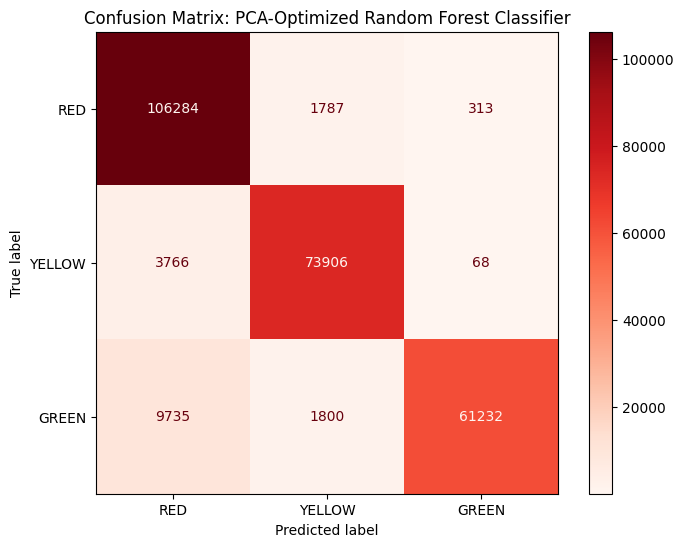

In [105]:
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Reds, ax=ax)
plt.title("Confusion Matrix: PCA-Optimized Random Forest Classifier")

In [100]:
fig.savefig("/kaggle/working/confusion_matrix.png", bbox_inches='tight', dpi=300)
print("Confusion Matrix saved to /kaggle/working/confusion_matrix.png")

Confusion Matrix saved to /kaggle/working/confusion_matrix.png


---